## Group Project for CS5483

In [51]:
!pip install kagglehub

In [52]:
pip install imblearn

In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import kagglehub

from joblib import Memory, Parallel, delayed, dump, load
from IPython import display

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import label_binarize
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer
from ipywidgets import interact
from sklearn.preprocessing import FunctionTransformer

### Load dataset

In [54]:
# Download latest version
path = kagglehub.dataset_download("nishchalchandel/fertilizer-recommendation")

# Load the dataset
df = pd.read_csv(path + "/fertilizer_recommendation_dataset.csv")

### Display basic info of dataset

In [55]:
# Display the first few rows of the dataset
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [56]:
# Display the shape of the dataset
print("Shape of the dataset:", df.shape)

# Display the basic information about the dataset
df.info()

Shape of the dataset: (3100, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB


In [57]:
# Display the summary statistics of the dataset
df.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


In [58]:
# Display the number of negtive values in each numeric column
negative_values_per_column = (df.select_dtypes(include=[np.number]) < 0).sum()
print("Number of negative values per column:\n", negative_values_per_column)

Number of negative values per column:
 Temperature     0
Moisture        0
Rainfall       75
PH              0
Nitrogen        0
Phosphorous    78
Potassium      71
Carbon         85
dtype: int64


In [59]:
# Drop the rows with negative values
df = df[(df.select_dtypes(include=[np.number]) >= 0).all(axis=1)]
print("Shape of the dataset after dropping negative values:", df.shape)
df.describe()

Shape of the dataset after dropping negative values: (2798, 12)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000
mean,27.248445,0.600667,115.754129,6.378720,61.285696,71.995526,71.734111,1.528203
std,9.106030,0.144215,71.671051,0.959385,10.211103,38.809166,32.778179,0.641954
min,4.011486,0.227436,1.322761,3.448974,35.527718,12.445888,29.635327,0.248064
25%,22.362842,0.494399,64.186879,5.856926,54.824953,43.933213,50.453392,1.001590
50%,26.175915,0.599853,98.133146,6.337308,59.425446,58.779200,59.160315,1.485274
75%,30.003216,0.707487,149.433380,6.899573,65.767304,86.970556,76.831866,2.022368
max,56.653592,0.972361,411.955947,9.562341,97.854559,177.314481,161.067982,3.241984


In [60]:
# Drop the unnecessary columns
df.drop(columns=['Remark'], inplace=True)

# Modify each column name to lowercase
df.columns = df.columns.str.lower()

# Modify "fertilizer" column to "target"
df.rename(columns={'fertilizer': 'target'}, inplace=True)

# Display the first few rows of the modified dataset
df.head()

,temperature,moisture,rainfall,ph,nitrogen,phosphorous,potassium,carbon,soil,crop,target
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer


### Distribution of target class

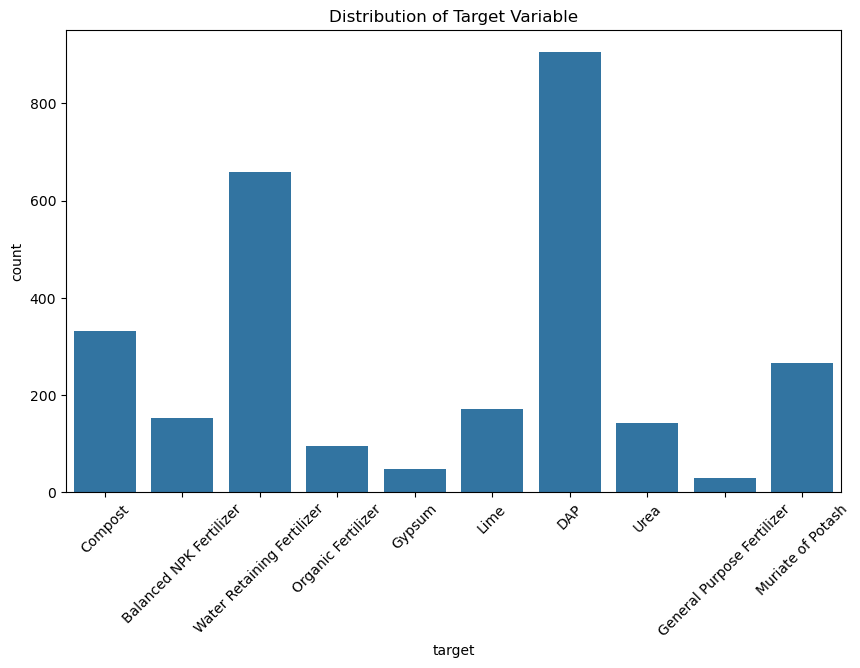

In [61]:
# Display the distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='target')
plt.title('Distribution of Target Variable')
plt.xticks(rotation=45)
plt.show()

In [62]:
# Display the numbers of each fertilizer type
fertilizer_counts = df['target'].value_counts()
print("Counts of each fertilizer type:\n", fertilizer_counts)

Counts of each fertilizer type:
 target
DAP                           906
Water Retaining Fertilizer    659
Compost                       331
Muriate of Potash             266
Lime                          170
Balanced NPK Fertilizer       153
Urea                          141
Organic Fertilizer             95
Gypsum                         48
General Purpose Fertilizer     29
Name: count, dtype: int64


### Distribution of numeric features

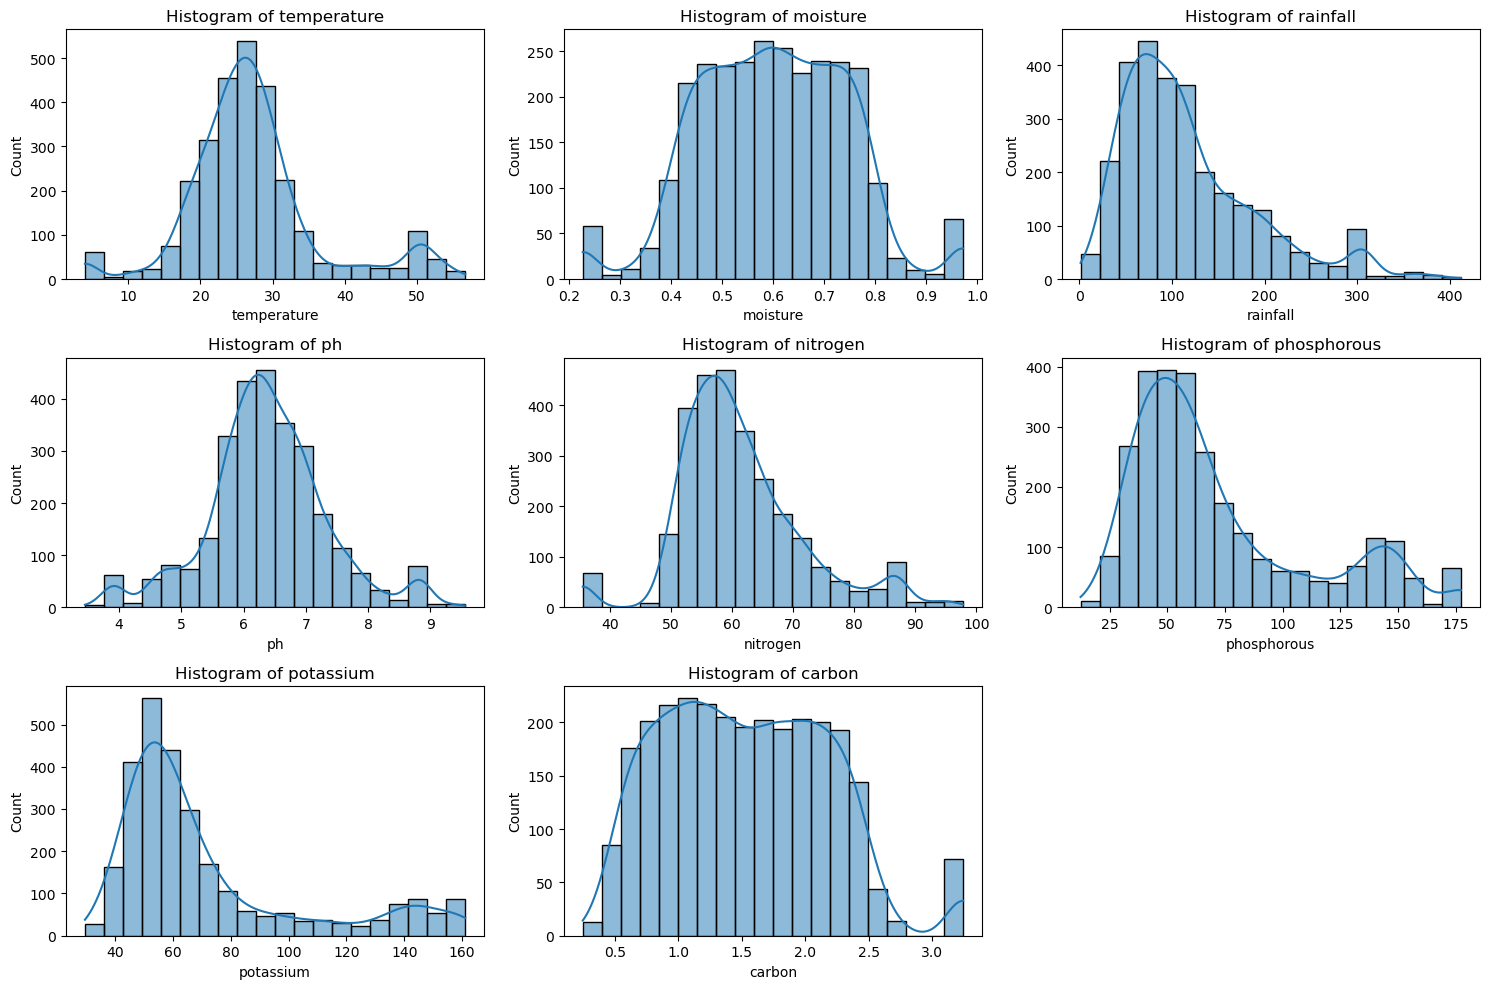

In [63]:
# Dispay the distribution of numerical features
numeric_df = df.select_dtypes(include=[np.number])
numeric_columns = numeric_df.columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(numeric_df[col], kde=True, bins=20)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

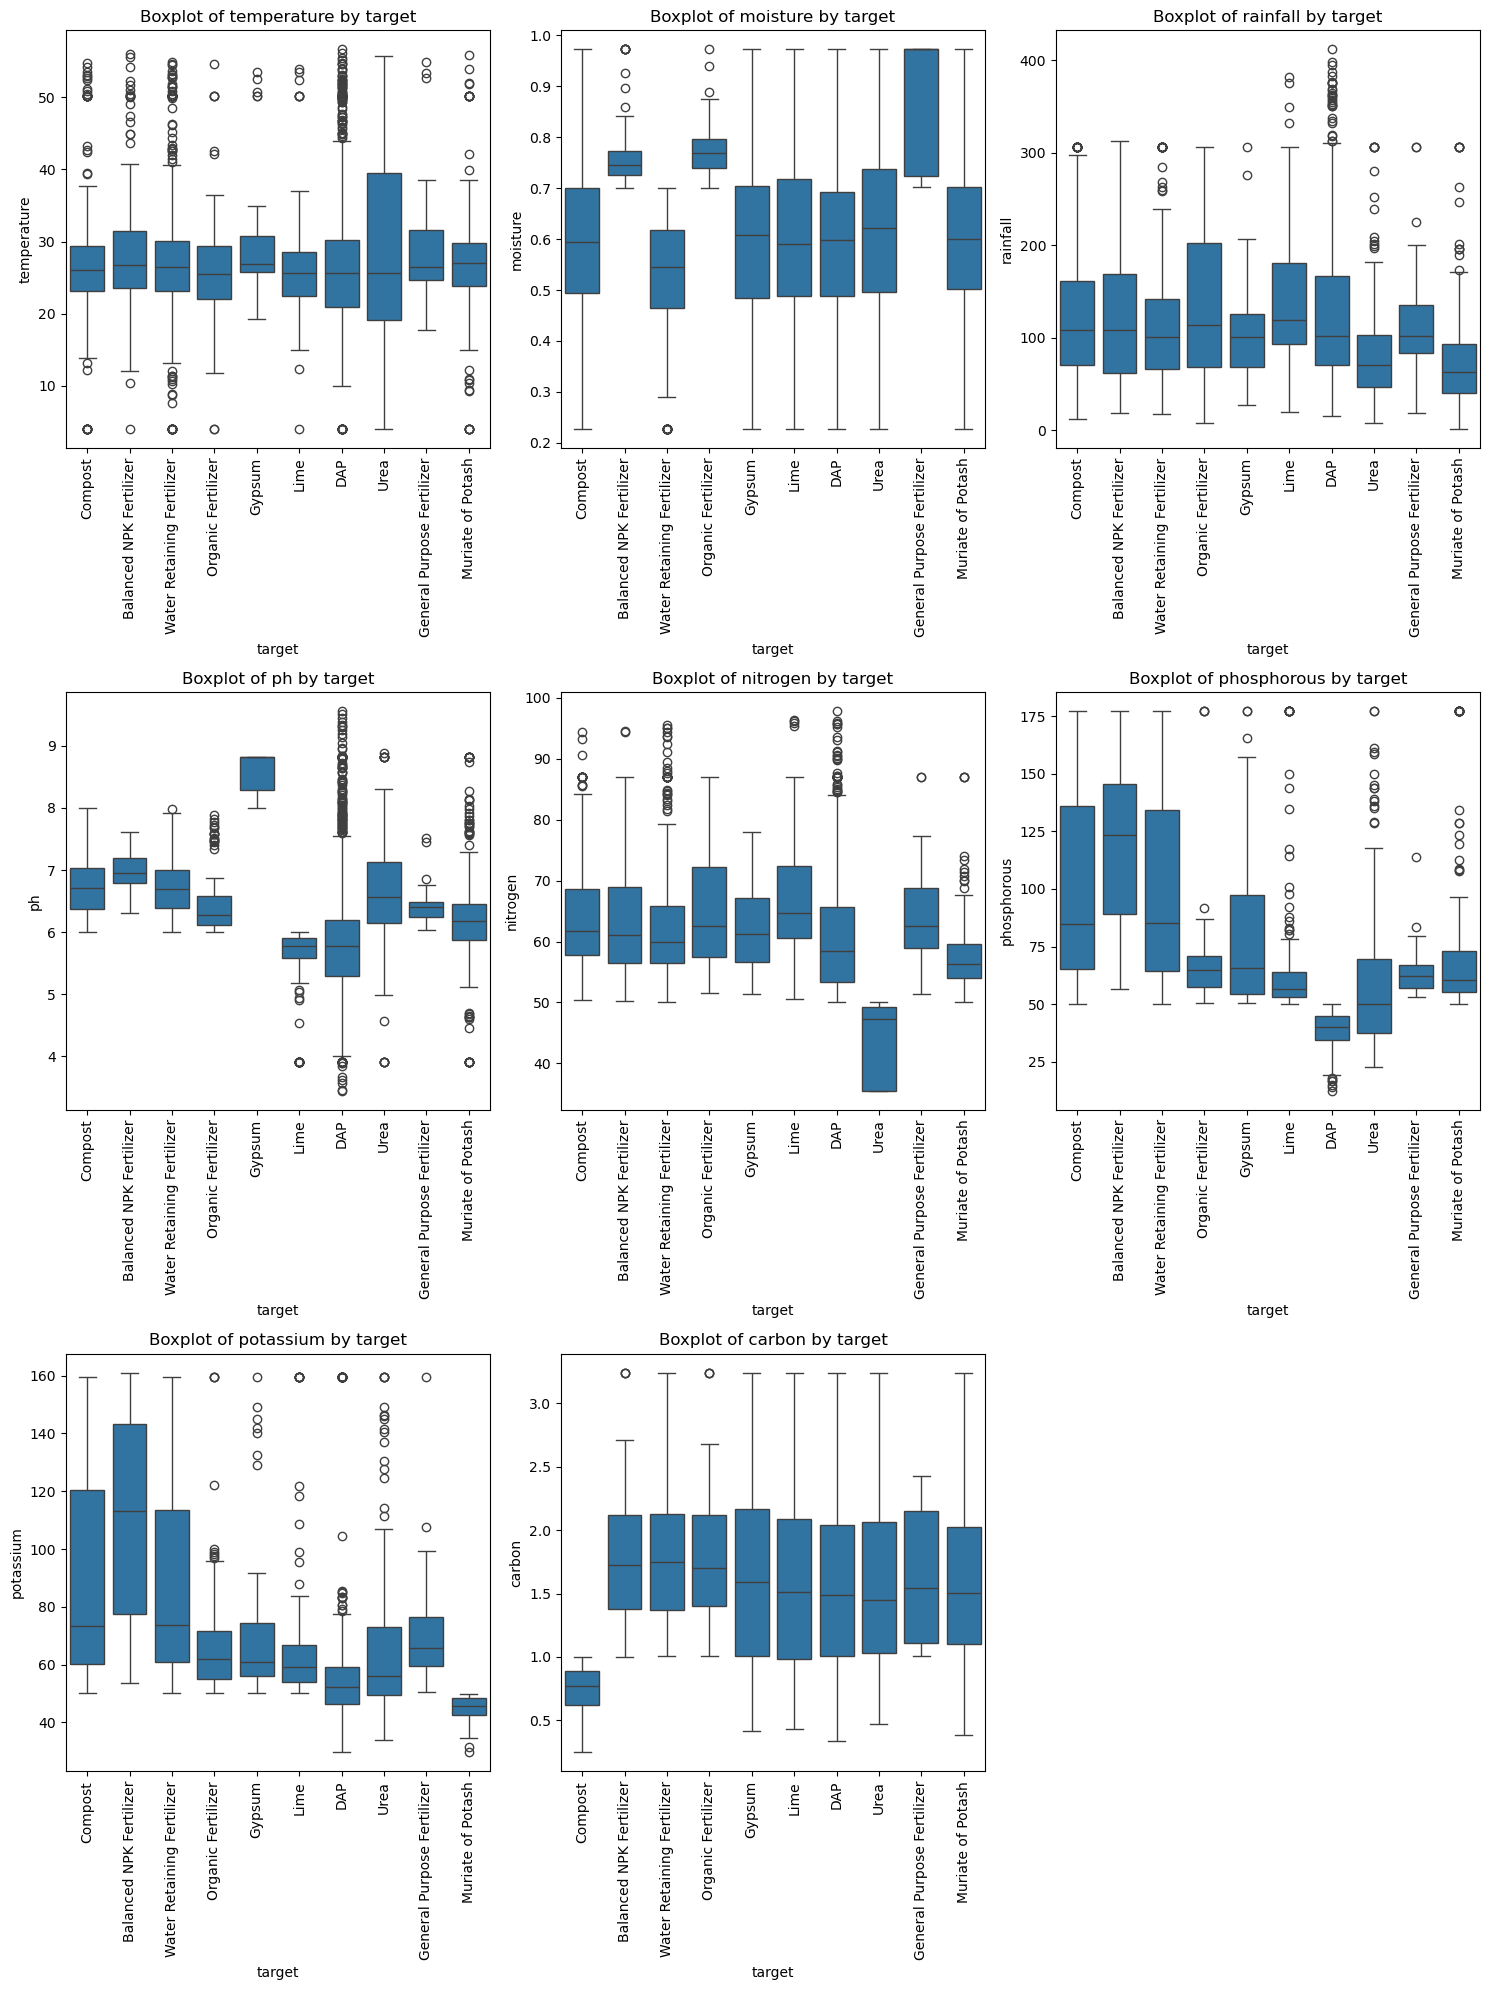

In [64]:
# Display the boxplot of numerical features in different target classes
plt.figure(figsize=(15, 20))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'Boxplot of {col} by target')
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

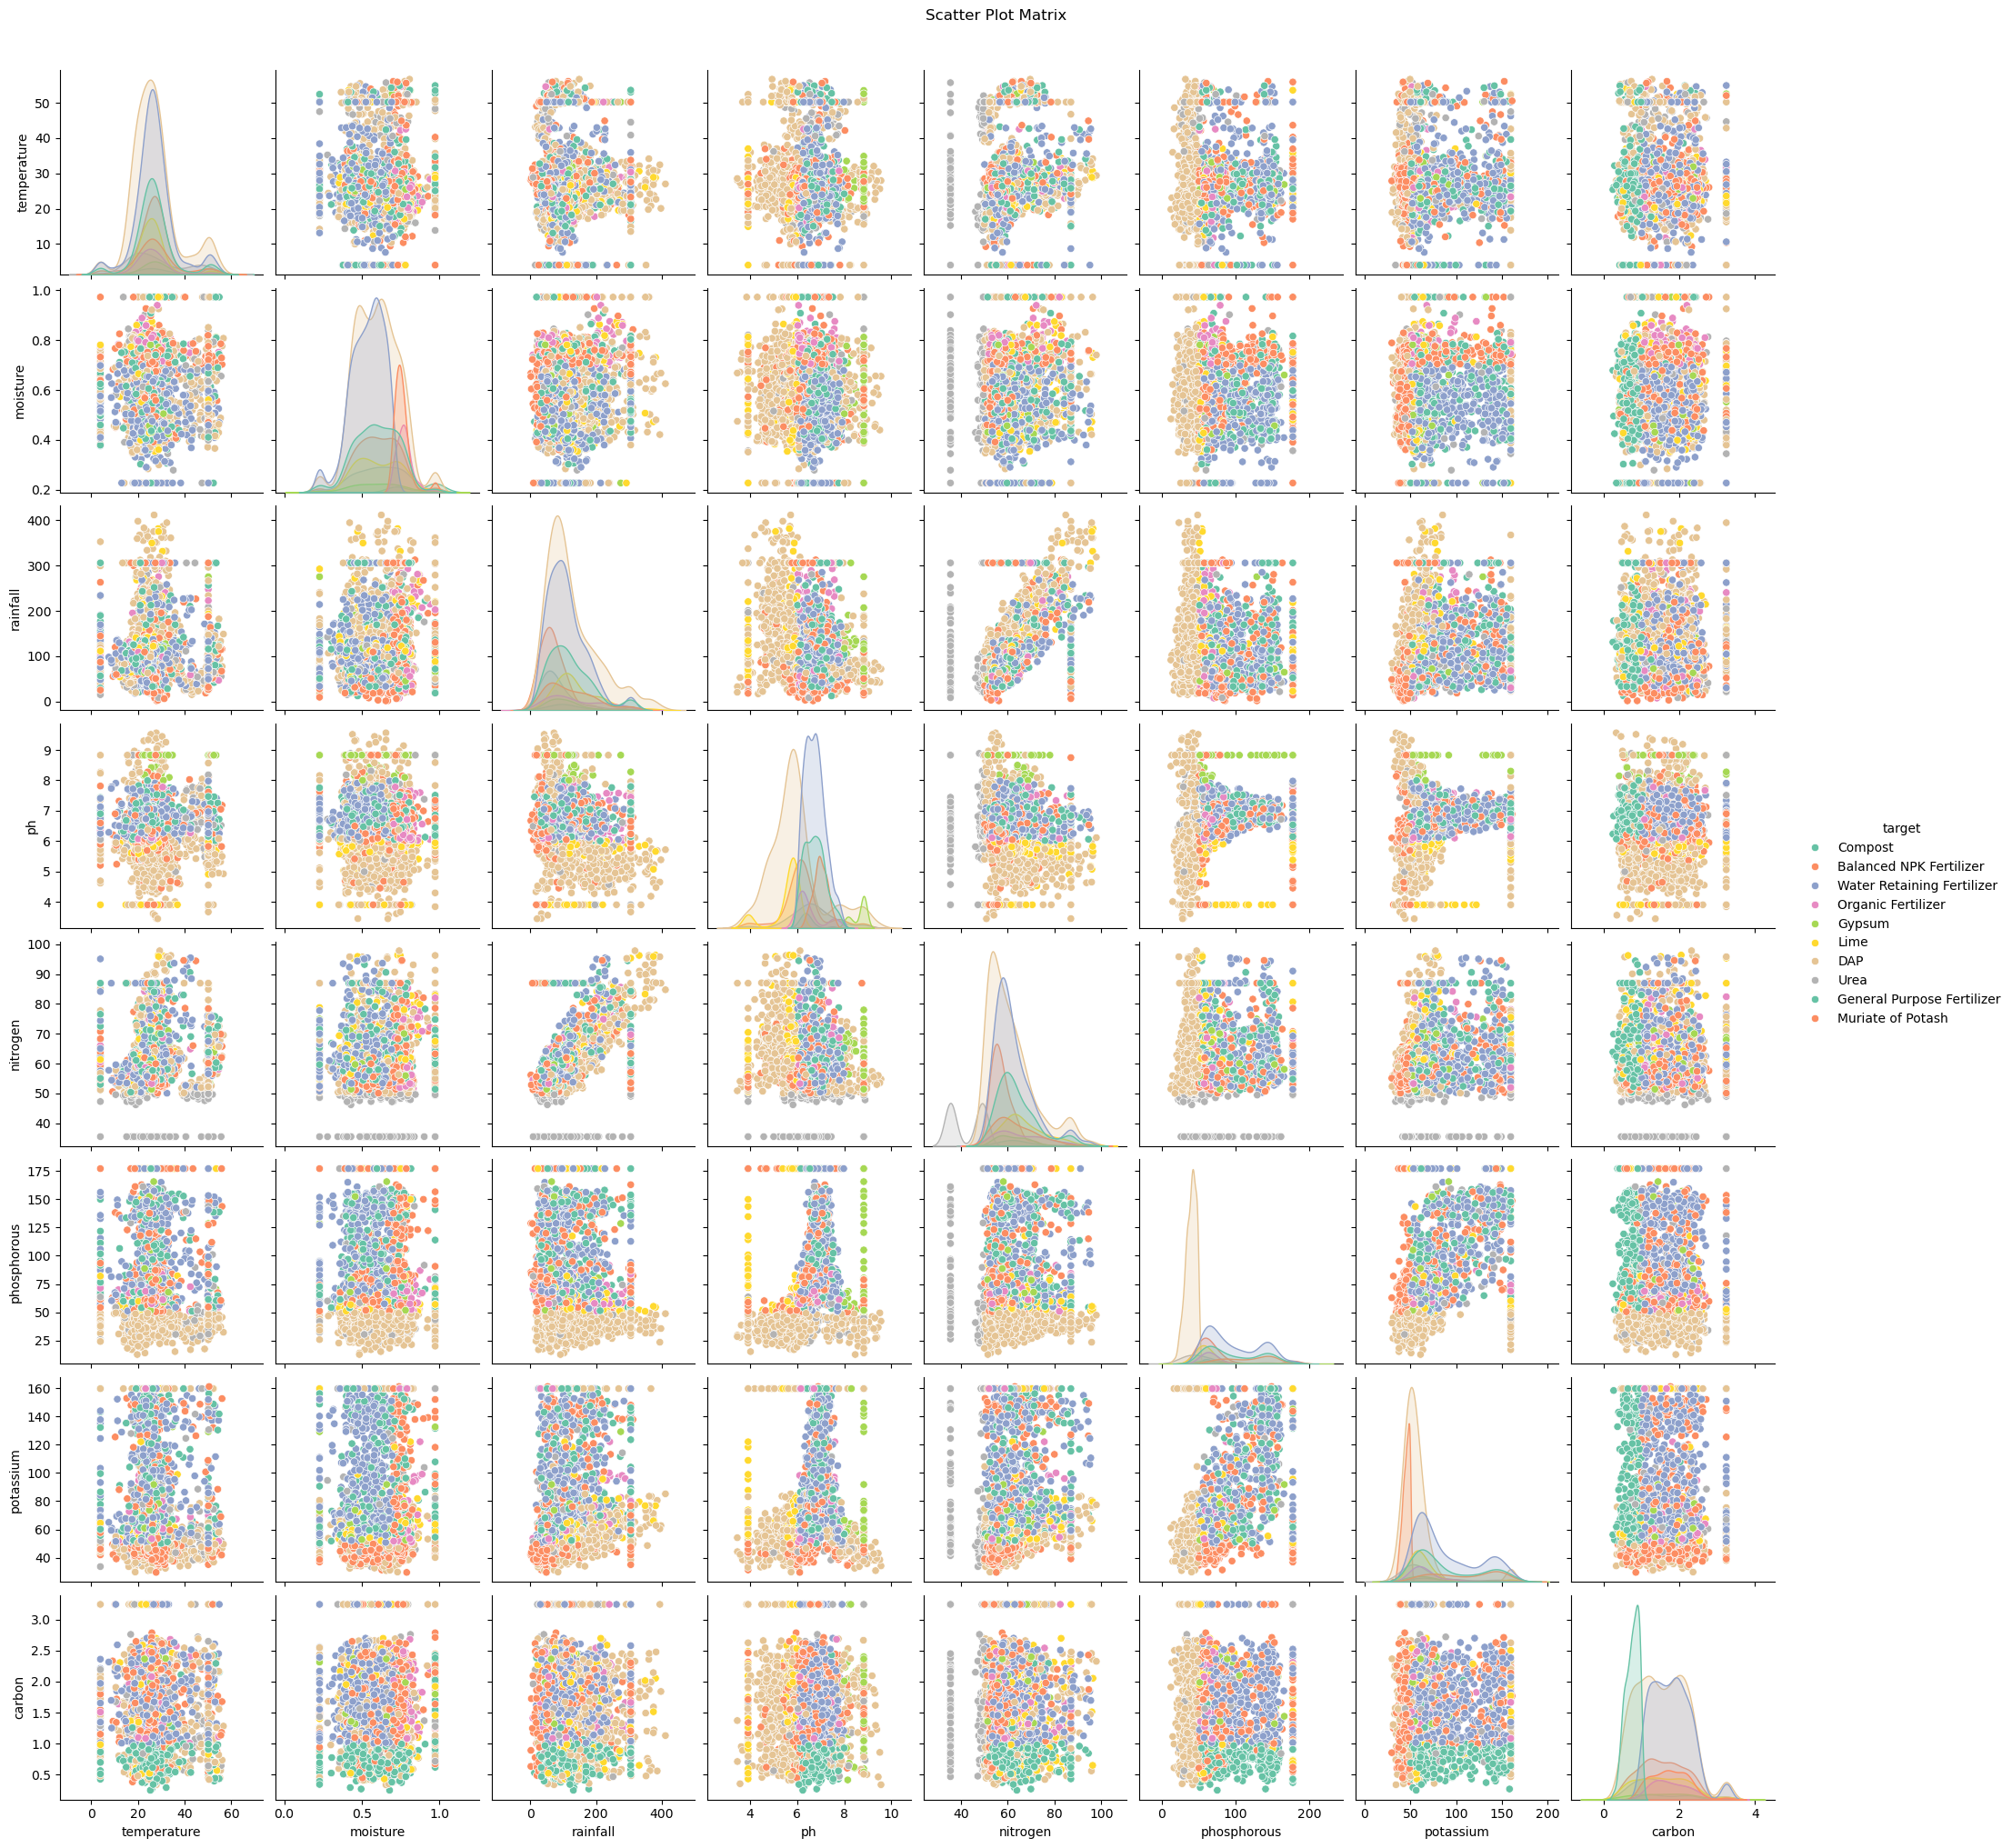

In [65]:
# Pairplot of numeric features
# especially combining certain key features such as nitrogen, phosphorus and potassium with PH, 
# and using color to distinguish fertilizer types
sns.pairplot(df, hue='target', diag_kind='kde', palette='Set2')
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.show()

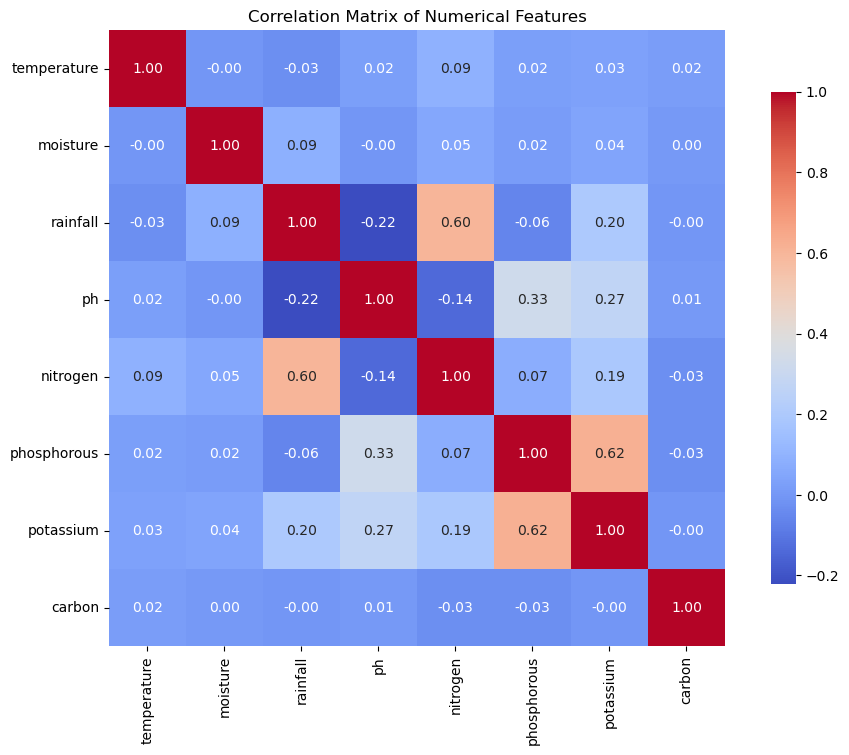

In [66]:
# Display the correlation matrix of numerical features
plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Distribution of categorical features

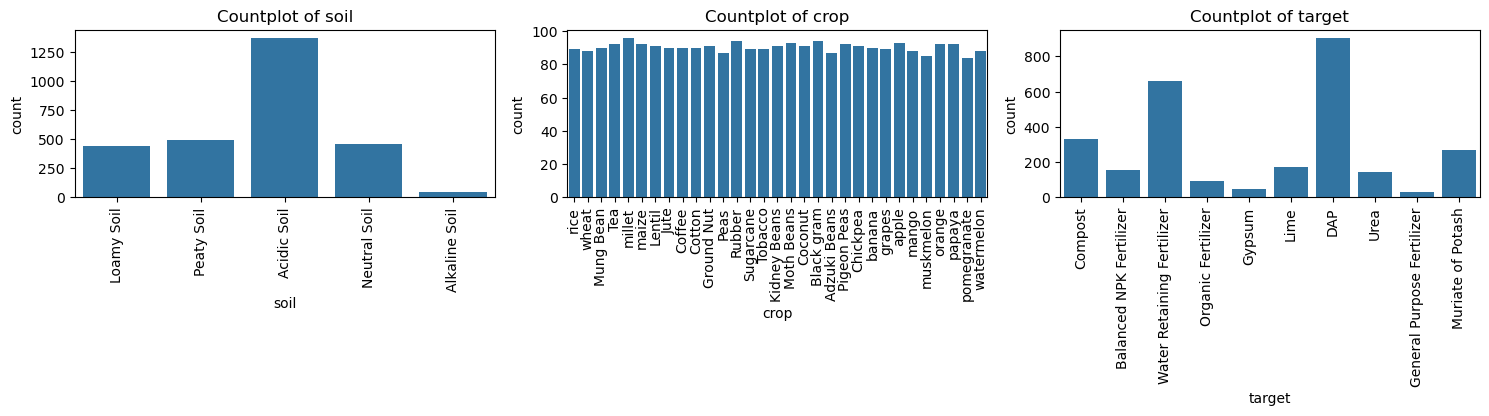

In [67]:
# Display the distribution of categorical features
categorical_df = df.select_dtypes(include=[object])
categorical_columns = categorical_df.columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [68]:
# Display the values of categorical features
for col in categorical_columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print("\n")

Unique values in soil:
['Loamy Soil' 'Peaty Soil' 'Acidic Soil' 'Neutral Soil' 'Alkaline Soil']


Unique values in crop:
['rice' 'wheat' 'Mung Bean' 'Tea' 'millet' 'maize' 'Lentil' 'Jute'
 'Coffee' 'Cotton' 'Ground Nut' 'Peas' 'Rubber' 'Sugarcane' 'Tobacco'
 'Kidney Beans' 'Moth Beans' 'Coconut' 'Black gram' 'Adzuki Beans'
 'Pigeon Peas' 'Chickpea' 'banana' 'grapes' 'apple' 'mango' 'muskmelon'
 'orange' 'papaya' 'pomegranate' 'watermelon']


Unique values in target:
['Compost' 'Balanced NPK Fertilizer' 'Water Retaining Fertilizer'
 'Organic Fertilizer' 'Gypsum' 'Lime' 'DAP' 'Urea'
 'General Purpose Fertilizer' 'Muriate of Potash']




<Figure size 1200x600 with 0 Axes>

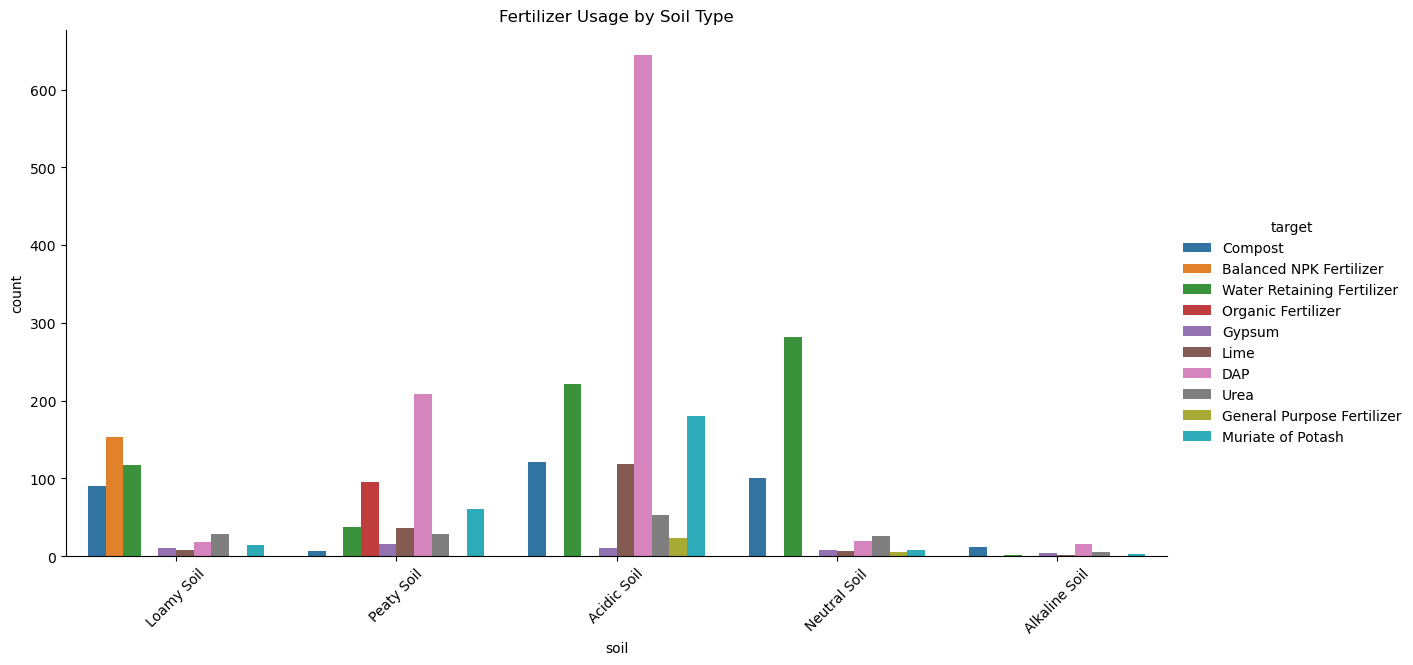

In [69]:
# Using Seaborn's catplot to show fertilizer use in different soil types
plt.figure(figsize=(12, 6))
sns.catplot(x='soil', hue='target', data=df, kind='count', height=6, aspect=2)
plt.title('Fertilizer Usage by Soil Type')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

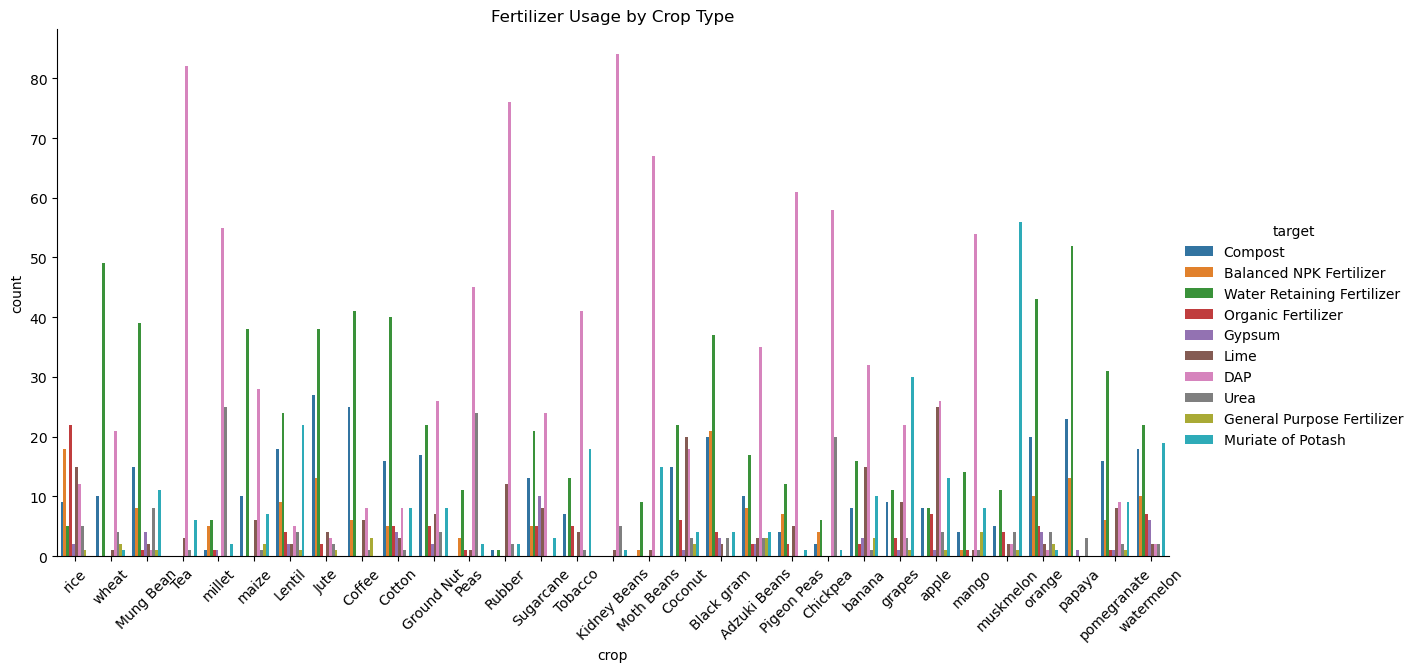

In [70]:
# Using Seaborn's catplot to show fertilizer use in different crop types
plt.figure(figsize=(12, 6))
sns.catplot(x='crop', hue='target', data=df, kind='count', height=6, aspect=2)
plt.title('Fertilizer Usage by Crop Type')
plt.xticks(rotation=45)
plt.show()

### Data preprocessing

In [71]:
# Delete the duplicate rows in the dataset
df.drop_duplicates(inplace=True)
df.shape

(2798, 11)

In [72]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

if missing_values.sum() > 0:
    # Fill numeric missing values with median and categorical with mode
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    print("Missing values were filled.")
else:
    print("No missing values detected.")

Missing values in each column:
 temperature    0
moisture       0
rainfall       0
ph             0
nitrogen       0
phosphorous    0
potassium      0
carbon         0
soil           0
crop           0
target         0
dtype: int64
No missing values detected.


In [73]:
# Encode categorical variables using one-hot encoding
categorical_cols = ['soil', 'crop']

oh_encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = oh_encoder.fit_transform(df[categorical_cols])

encoded_feature_names = oh_encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df.index)

df = df.join(encoded_df)

df.head()

,temperature,moisture,rainfall,ph,nitrogen,phosphorous,potassium,carbon,soil,crop,...,crop_maize,crop_mango,crop_millet,crop_muskmelon,crop_orange,crop_papaya,crop_pomegranate,crop_rice,crop_watermelon,crop_wheat
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [74]:
# Encode the target variable using label encoding
le_fertilizer = LabelEncoder()

df['target_encoded'] = le_fertilizer.fit_transform(df['target'])

# Display the correspondence of label encoding
fertilizer_mapping = dict(zip(le_fertilizer.classes_, le_fertilizer.transform(le_fertilizer.classes_)))
print(fertilizer_mapping)

{'Balanced NPK Fertilizer': 0, 'Compost': 1, 'DAP': 2, 'General Purpose Fertilizer': 3, 'Gypsum': 4, 'Lime': 5, 'Muriate of Potash': 6, 'Organic Fertilizer': 7, 'Urea': 8, 'Water Retaining Fertilizer': 9}


In [75]:
# Define feature set X and target variable y
features = ['temperature', 'moisture', 'rainfall', 'ph', 'nitrogen', 'phosphorous', 'potassium', 'carbon']
features += list(encoded_df.columns)

target = 'target_encoded'

X = df[features]
y = df[target]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Models

#### Logistics Regression

::::{caution}

Since the normalization factors for cross validation were calculated from the entire dataset, the test data for each cross-validation fold may not be independent of the remaining normalized data for training the classifier. This subtle data leak may cause the performance estimate to be overly-optimistic.

::::

In [76]:
# Make a pipeline for scaling and L2 regularization logistics regression model training
pipeline_lg = Pipeline(steps=[
    ('scaler', MinMaxScaler()), 
    ('model', LogisticRegression(penalty='l2', solver='liblinear'))
])

# Train the model
pipeline_lg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline_lg.predict(X_test)

# Calculate accuracy
accuracy_lg = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression: {accuracy_lg:.2f}")

# Perform 5-fold cross-validation
cv_scores_lg = cross_val_score(pipeline_lg, X, y, cv=5, scoring='accuracy')

# Print the cross-validation scores and their mean
print("Cross-validation scores for Logistic Regression:", cv_scores_lg)
print(f"Mean accuracy: {cv_scores_lg.mean():.2f}")

Accuracy of Logistic Regression: 0.67
Cross-validation scores for Logistic Regression: [0.59107143 0.4625     0.32857143 0.54740608 0.52772809]
Mean accuracy: 0.49


#### Decision Tree

In [77]:
# Make a pipeline for scaling and Decision Tree model training
pipeline_dt = Pipeline(steps=[
    ('scaler', MinMaxScaler()), 
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

# Train the model
pipeline_dt.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline_dt.predict(X_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred)
print(f"Accuracy of DT: {accuracy_dt:.2f}")

# Perform 5-fold cross-validation
cv_scores_dt = cross_val_score(pipeline_dt, X, y, cv=5, scoring='accuracy')

# Print the cross-validation scores and their mean
print("Cross-validation scores for DT:", cv_scores_dt)
print(f"Mean accuracy: {cv_scores_dt.mean():.2f}")

Accuracy of DT: 0.94
Cross-validation scores for DT: [0.91964286 0.94821429 0.95892857 0.94275492 0.92844365]
Mean accuracy: 0.94



Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        38
           1       0.96      1.00      0.98        99
           2       1.00      1.00      1.00       280
           3       0.00      0.00      0.00         7
           4       1.00      0.26      0.42        19
           5       1.00      0.86      0.92        57
           6       1.00      1.00      1.00        79
           7       0.60      1.00      0.75        33
           8       1.00      0.53      0.70        43
           9       0.90      0.99      0.95       185

    accuracy                           0.94       840
   macro avg       0.84      0.77      0.77       840
weighted avg       0.95      0.94      0.93       840



d:\soft\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\soft\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\soft\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


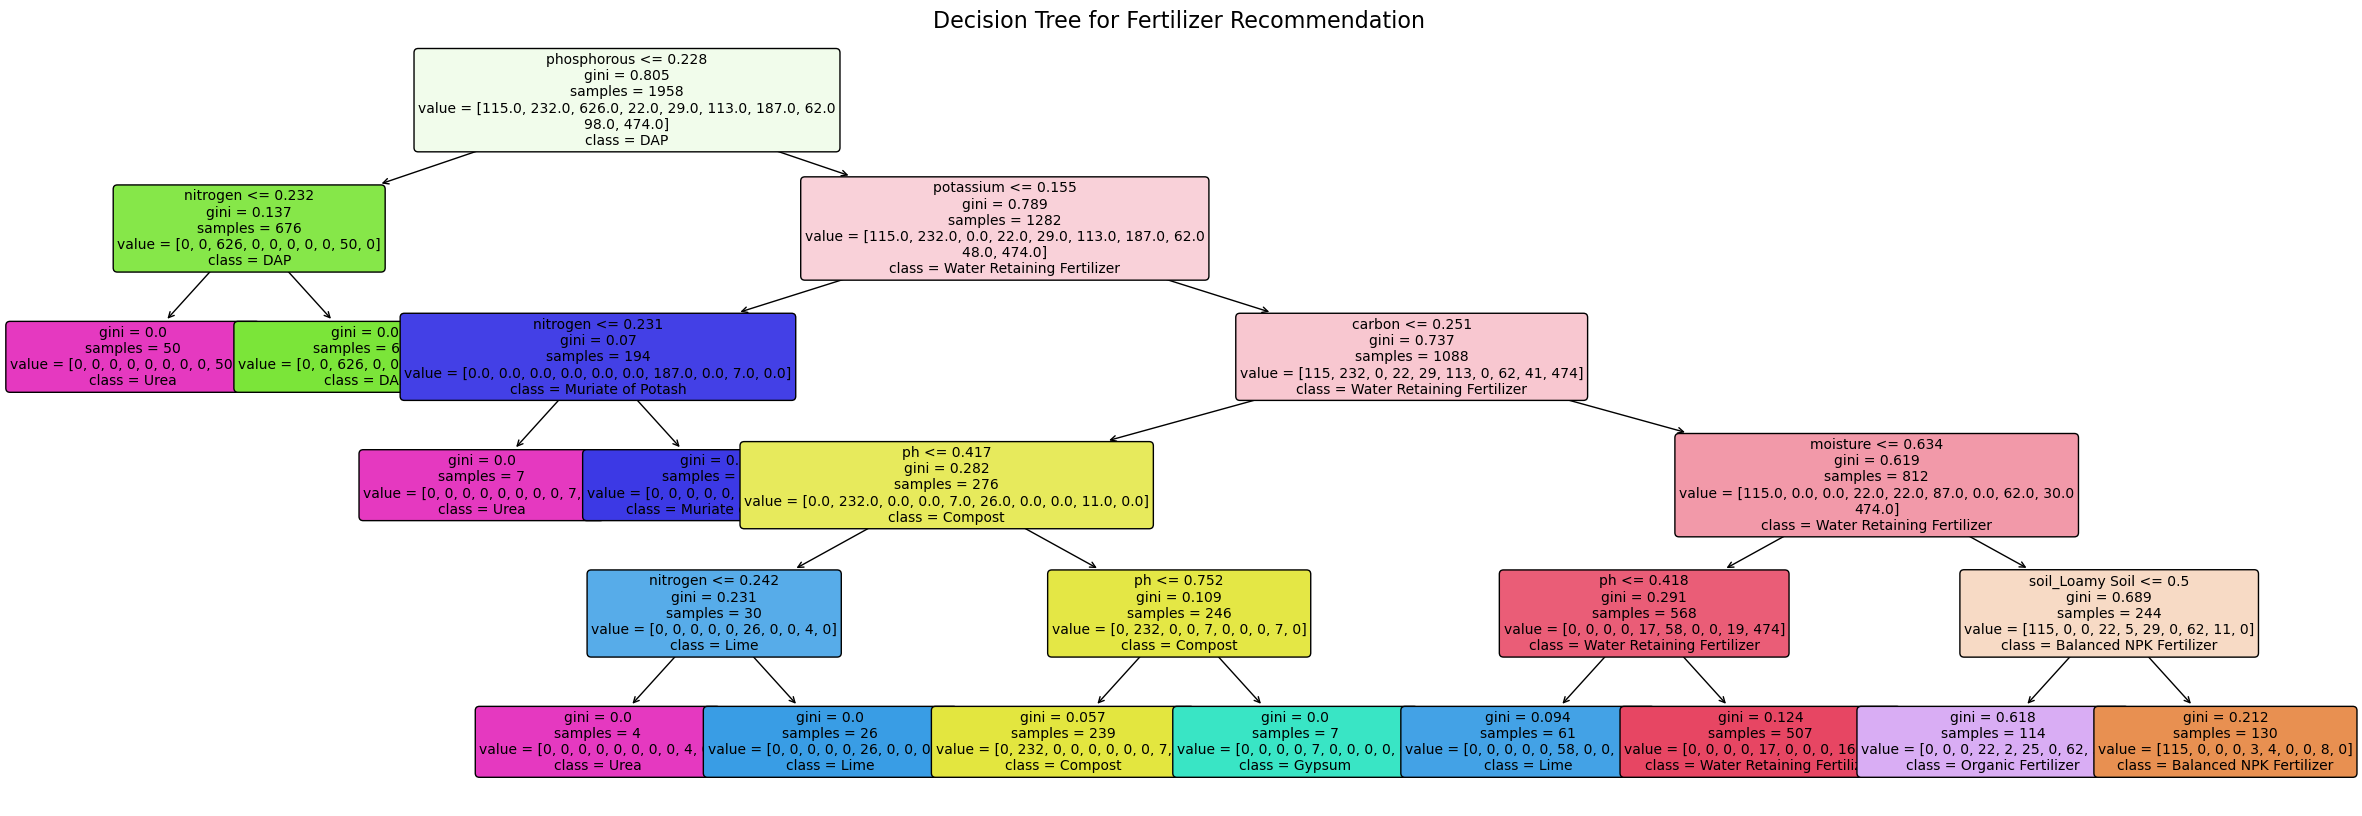

In [78]:
# Check report of DT
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualize DT
plt.figure(figsize=(30, 10))
plot_tree(pipeline_dt.named_steps['model'],
          feature_names=X.columns,
          class_names=le_fertilizer.classes_,  # 原始 Fertilizer 标签
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Fertilizer Recommendation", fontsize=16)
plt.show()

::::{note} Idea of how to deal with skewed dataset
fertilizer_recommendation dataset is a highly unbalanced dataset for the DAP category accounts for nearly 30%, while General Purpose Fertilizer accounts for only 0.9%.
see in the classification report of decision tree, although the accuracy is high(0.94), the f1 score of class "General Purpose Fertilizer"(0), "Gypsum"(0.42), "Organic Fertilizer"(0.75) and "Urea"(0.7) is very low. To fix this:

- Initial baseline model:

    - Do not deal with imbalance, train models like Random Forest/XGBoost that are robust with imbalance class, observe F1-score for a few classes.

- Add class weights:

    - Compare the effect of class_weight='balanced' and focus on minority class recall improvement.

- Resampling experiment:

    - Test SMOTE to see whether the model performance improved.
::::

#### Random Forest

##### 1. Find best parameters of rf

In [79]:
# prepare some utils

# To tabulate results of ensemble methods
def tabulate(results):
    df = pd.DataFrame(
        columns=[f"max_depth={max_depth}" for max_depth in max_depth_list], dtype=float
    )
    df.insert(0, "n_estimators", n_estimators_list)
    df.loc[:, lambda df: ~df.columns.isin(["n_estimators"])] = np.reshape(
        results, (len(n_estimators_list), len(max_depth_list)), order="F"
    )
    return df

# To plot the dataframe
def plot(df):
    for col in df.columns[1:]:
        plt.plot(df["n_estimators"], df[col], label=col, marker="o")
    plt.legend()
    plt.xlabel("n_estimators")
    plt.ylabel("Accuracies")

# Load file
def load_file(filename):
    if os.path.exists(filename):
        os.replace(filename, "private/" + filename)
    return load("private/" + filename)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  66 out of  66 | elapsed:    1.7s finished


,n_estimators,max_depth=1,max_depth=2,max_depth=3,max_depth=5,max_depth=10,max_depth=20
0,1,0.3381,0.3536,0.5310,0.6690,0.8167,0.8405
1,2,0.3548,0.5345,0.6476,0.7714,0.8357,0.8155
2,3,0.6857,0.6381,0.6393,0.7524,0.9262,0.9202
3,5,0.4238,0.5333,0.6262,0.8036,0.9202,0.9298
4,10,0.4405,0.6333,0.7012,0.8762,0.9262,0.9619
5,20,0.4988,0.5714,0.6845,0.8631,0.9536,0.9619
6,30,0.4583,0.5702,0.6857,0.8583,0.9631,0.9702
7,50,0.4393,0.5726,0.6917,0.8833,0.9655,0.9702
8,100,0.5238,0.6048,0.7107,0.9167,0.9679,0.9702
9,200,0.5417,0.5893,0.7250,0.9190,0.9714,0.9750


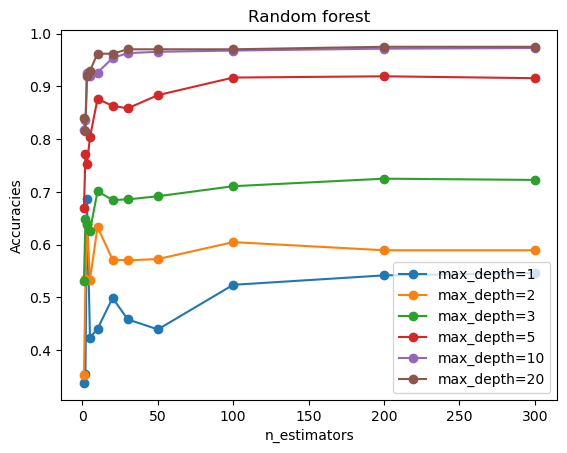

In [80]:
# Set up a cache directory for joblib
os.makedirs("cache_directory", exist_ok=True)
memory = Memory(location="cache_directory", verbose=0)

max_depth_list = [1, 2, 3, 5, 10, 20]
n_estimators_list = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 300]

if input("execute? [Y/n] ").lower() != "n":
    RF_df = pd.DataFrame(
        columns=[f"max_depth={max_depth}" for max_depth in max_depth_list], dtype=float
    )
    RF_df.insert(0, "n_estimators", n_estimators_list)
    @memory.cache
    def train_and_evaluate_rf(n_estimators, max_depth):
        rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        # make pipeline for scaling and RF model training
        pipeline_rf = Pipeline(steps=[
            ('scaler', MinMaxScaler()), 
            ('model', rf)
        ])
        # Train the model
        pipeline_rf.fit(X_train, y_train)
        # Make predictions on the test set
        y_pred = pipeline_rf.predict(X_test)
        # Calculate accuracy
        accuracy_rf = accuracy_score(y_test, y_pred)
        return accuracy_rf
    
    RF_results = Parallel(n_jobs=4, verbose=1)(
        delayed(train_and_evaluate_rf)(n_estimators, max_depth)
        for max_depth in max_depth_list
        for n_estimators in n_estimators_list
    )
    RF_df = tabulate(RF_results)
    display.display(RF_df.round(4))

    plt.figure()
    plot(RF_df)
    plt.title(r"Random forest")
    plt.show()

    dump(RF_df, "RF_df.gz")

##### also can use GridSearchCV to find best para

In [81]:
if input("execute? [Y/n] ").lower() != "n":
    max_depth_list = [1, 2, 3, 5, 10, 20]
    n_estimators_list = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 300]
    param_grid = {"n_estimators": n_estimators_list, "max_depth": max_depth_list}

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=0), param_grid, verbose=1, n_jobs=8
    )
    pipeline_gs = Pipeline(steps=[
        ('scaler', MinMaxScaler()), 
        ('model', grid_search)
    ])
    pipeline_gs.fit(X_train, y_train)
    y_pred = pipeline_gs.predict(X_test)
    accuracy_gs = accuracy_score(y_test, y_pred)
    print(f"Accuracy of Random Forest: {accuracy_gs:.2f}")
    print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 66 candidates, totalling 330 fits
Accuracy of Random Forest: 0.97
Best parameters: {'max_depth': 20, 'n_estimators': 200}


##### 2. Apply the parameters and observe the recall and f1 score of minority class

In [82]:
# make pipeline for scaling and Random Forest model training
pipeline_rf = Pipeline(steps=[
    ('scaler', MinMaxScaler()), 
    ('model', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42))
])

# Train the model
pipeline_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline_rf.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Accuracy of RF: {accuracy_rf:.2f}")

# Perform 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_rf, X_train, y_train, cv=kf, scoring='f1_macro')
# Print the cross-validation scores
print(f"Cross-Validation F1: {scores.mean():.3f} ± {scores.std():.3f}")

# Display the classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy of RF: 0.97
Cross-Validation F1: 0.931 ± 0.036

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        38
           1       0.94      0.99      0.97        99
           2       0.99      1.00      1.00       280
           3       0.88      1.00      0.93         7
           4       1.00      0.21      0.35        19
           5       1.00      1.00      1.00        57
           6       1.00      0.97      0.99        79
           7       0.89      1.00      0.94        33
           8       1.00      0.95      0.98        43
           9       0.97      0.99      0.98       185

    accuracy                           0.97       840
   macro avg       0.96      0.91      0.91       840
weighted avg       0.98      0.97      0.97       840



The recall and f1 score of class 4 is very low.
##### 3. Apply class weights(based on the percentage of class) to the model

In [83]:
# Compute class weights to handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: 1.702608695652174, 1: 0.8439655172413794, 2: 0.31277955271565494, 3: 8.9, 4: 6.751724137931035, 5: 1.7327433628318585, 6: 1.0470588235294118, 7: 3.1580645161290324, 8: 1.9979591836734694, 9: 0.4130801687763713}


In [84]:
# Apply class weights to the model
pipeline_rf = Pipeline(steps=[
    ('scaler', MinMaxScaler()), 
    ('model', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight=class_weights_dict))
])

# Train the model
pipeline_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline_rf.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Accuracy of RF: {accuracy_rf:.2f}")

# Perform 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_rf, X_train, y_train, cv=kf, scoring='f1_macro')
# Print the cross-validation scores
print(f"Cross-Validation F1: {scores.mean():.3f} ± {scores.std():.3f}")

# Display the classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy of RF: 0.99
Cross-Validation F1: 0.955 ± 0.047

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        38
           1       0.95      0.99      0.97        99
           2       1.00      1.00      1.00       280
           3       1.00      0.86      0.92         7
           4       1.00      0.68      0.81        19
           5       1.00      0.96      0.98        57
           6       1.00      0.99      0.99        79
           7       0.94      1.00      0.97        33
           8       1.00      0.98      0.99        43
           9       0.99      1.00      0.99       185

    accuracy                           0.99       840
   macro avg       0.98      0.95      0.96       840
weighted avg       0.99      0.99      0.99       840



The recall and f1 score of class 4 increase.

##### 4. Use SMOTE to resample

In [85]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight=class_weights_dict))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='f1_macro')
print(f"Cross-Validation F1: {scores.mean():.3f} ± {scores.std():.3f}")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

Cross-Validation F1: 0.957 ± 0.034
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        38
           1       0.96      0.99      0.98        99
           2       1.00      0.99      0.99       280
           3       0.71      0.71      0.71         7
           4       1.00      1.00      1.00        19
           5       1.00      0.91      0.95        57
           6       1.00      0.99      0.99        79
           7       0.97      1.00      0.99        33
           8       1.00      1.00      1.00        43
           9       0.99      1.00      1.00       185

    accuracy                           0.98       840
   macro avg       0.95      0.96      0.96       840
weighted avg       0.99      0.98      0.98       840



### Evaluation

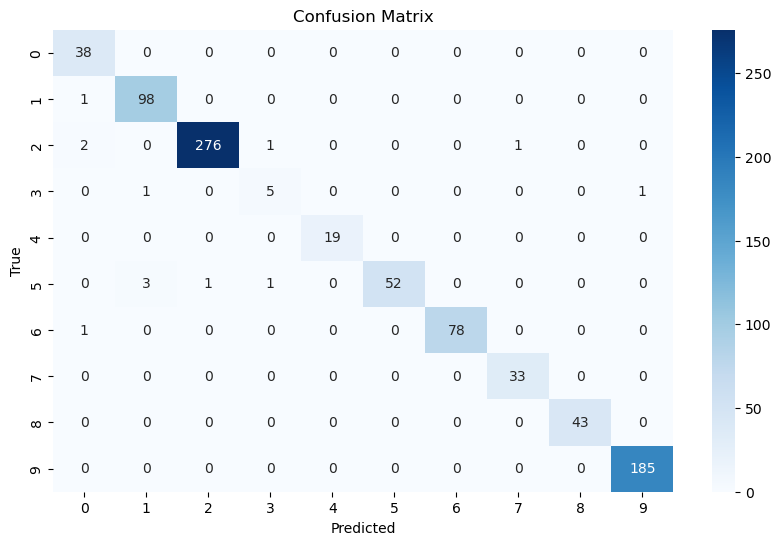

In [86]:
# Display the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

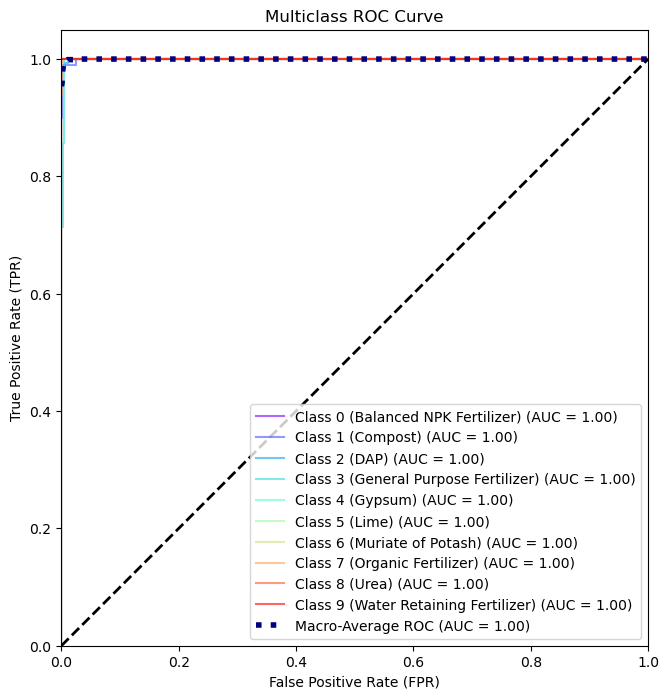

In [87]:
# obtain the predicted probabilities
y_proba = pipeline.predict_proba(X_test)

# binarize the output for ROC curve
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.unique(y))

# compute ROC curve and ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# compute macro-averaged ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# plot the macro-averaged ROC curve
plt.figure(figsize=(10, 8))
colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    RocCurveDisplay(
        fpr=fpr[i],
        tpr=tpr[i],
        roc_auc=roc_auc[i],
        estimator_name=f"Class {i} ({le_fertilizer.classes_[i]})"
    ).plot(ax=plt.gca(), color=color, alpha=0.6)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-Average ROC (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [88]:
# binarize the output for ROC curve
from sklearn.metrics import roc_auc_score


y_test_bin = label_binarize(y_test, classes=range(10))

# compute ROC AUC for each class
for i in range(10):
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    print(f"Class {i} AUC: {auc:.4f}")

Class 0 AUC: 1.0000
Class 1 AUC: 0.9996
Class 2 AUC: 0.9999
Class 3 AUC: 0.9990
Class 4 AUC: 1.0000
Class 5 AUC: 1.0000
Class 6 AUC: 1.0000
Class 7 AUC: 0.9999
Class 8 AUC: 1.0000
Class 9 AUC: 1.0000


### Interpret Random Forest
use shap to explain the model

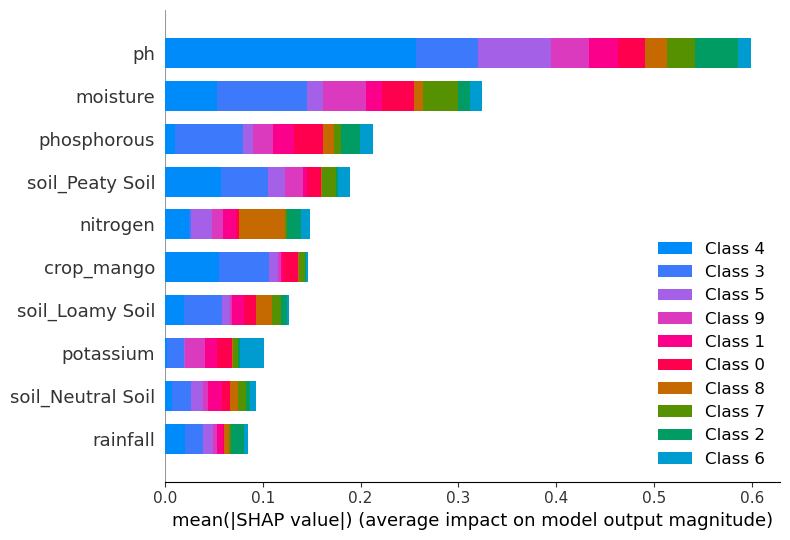

In [ ]:
# use shap to explain the model
import shap

explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(X_train)

# plot the average SHAP values for each feature impacting the model
shap.summary_plot(shap_values, X_train, feature_names=X.columns, plot_type="bar", max_display=10)


In [123]:
@interact(class_idx=(0, len(le_fertilizer.classes_) - 1))
def plot_shap_importance(class_idx):
    shap_importance = np.abs(shap_values[:, :, class_idx]).mean(axis=0)
    
    sorted_idx = np.argsort(shap_importance)[::-1]
    plt.figure(figsize=(10, 6))
    plt.title(f"Feature Importance for Class {class_idx}")
    plt.barh(range(10), shap_importance[sorted_idx[:10]], align='center')
    plt.yticks(range(10), X_train.columns[sorted_idx[:10]])
    plt.xlabel("Mean |SHAP Value|")
    plt.show()

interactive(children=(IntSlider(value=4, description='class_idx', max=9), Output()), _dom_classes=('widget-int…

Use the SHAP Summary Plot to view the average influence of all features on the model output:

In [ ]:
# plot the shap values for each class
@interact(class_idx=(0, len(le_fertilizer.classes_) - 1))
def plot_shap_class(class_idx):
    shap.summary_plot(
        shap_values[:, :, class_idx],
        X_train,
        feature_names=X_train.columns.tolist(),
        plot_type="dot",
        max_display=15
    )

interactive(children=(IntSlider(value=4, description='class_idx', max=9), Output()), _dom_classes=('widget-int…

In [ ]:
@interact(featA=features, featB=features, class_idx=(0, len(le_fertilizer.classes_) - 1))
def plot_shap_dependence(featA, class_idx, featB):
    shap.dependence_plot(
        featA,
        shap_values[:, :, class_idx],
        X_train,
        interaction_index=featB
    )

interactive(children=(Dropdown(description='featA', options=('temperature', 'moisture', 'rainfall', 'ph', 'nit…

#### Test Robustness

In [41]:
num_cols = ['temperature', 'moisture', 'rainfall', 'ph', 'nitrogen', 'phosphorous', 'potassium', 'carbon']
cat_cols = ['crop', 'soil']

X = df[num_cols + cat_cols]
y = df['target_encoded']

In [42]:
# function of gaussian noise injection for numerical features
def add_gaussian_noise(X, noise_level=0.01):
    noisy_X = X.copy()
    for col in num_cols:
        noise = np.random.normal(0, noise_level, size=noisy_X[col].shape)
        noisy_X[col] += noise
    return noisy_X

# function of random rotation for categorical features
def random_rotation(X, rotation_prob=0.1):
    rotated_X = X.copy()
    for col in cat_cols:
        if np.random.rand() < rotation_prob:
            rotated_X[col] = np.random.choice(X[col].unique(), size=X[col].shape, replace=True)
    return rotated_X

In [43]:
# make a copy of the original data
X_original = X.copy()
y_original = y.copy()

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_original, y_original, test_size=0.3, random_state=42)

# Make a custom pipeline for noise injection, rotation, encoding, scaling, and Random Forest model training
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('noise_injection', FunctionTransformer(add_gaussian_noise, validate=False)),
    ('rotation', FunctionTransformer(random_rotation, validate=False)),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight=class_weights_dict))
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='f1_macro', n_jobs=-1)
print(f"Cross-Validation F1: {scores.mean():.3f} ± {scores.std():.3f}")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


Cross-Validation F1: 0.913 ± 0.076
              precision    recall  f1-score   support

           0       0.90      0.97      0.94        38
           1       0.96      0.97      0.96        99
           2       1.00      0.99      0.99       280
           3       0.75      0.86      0.80         7
           4       1.00      1.00      1.00        19
           5       0.98      0.95      0.96        57
           6       1.00      0.99      0.99        79
           7       0.94      0.97      0.96        33
           8       1.00      1.00      1.00        43
           9       0.98      0.98      0.98       185

    accuracy                           0.98       840
   macro avg       0.95      0.97      0.96       840
weighted avg       0.98      0.98      0.98       840



In [ ]:
from sklearn.metrics import auc

# function to plot ROC curve with noise injection and random rotation
@interact(noise_level=(0.0, 0.5, 0.01), rotation_prob=(0.0, 1.0, 0.1))
def plot_multiclass_roc_curve(noise_level, rotation_prob):
    def add_gaussian_noise(X, noise_level=noise_level):
        noisy_X = X.copy()
        for col in num_cols:
            noise = np.random.normal(0, noise_level, size=noisy_X[col].shape)
            noisy_X[col] += noise
        return noisy_X

    def random_rotation(X, rotation_prob=rotation_prob):
        rotated_X = X.copy()
        for col in cat_cols:
            if np.random.rand() < rotation_prob:
                rotated_X[col] = np.random.choice(X[col].unique(), size=X[col].shape, replace=True)
        return rotated_X

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)
        ]
    )

    pipeline = Pipeline(steps=[
        ('noise_injection', FunctionTransformer(add_gaussian_noise, validate=False)),
        ('rotation', FunctionTransformer(random_rotation, validate=False)),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight=class_weights_dict))
    ])

    pipeline.fit(X_train, y_train)

    y_proba = pipeline.predict_proba(X_test)

    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i in range(len(np.unique(y_test))):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve with Noise Injection and Random Rotation')
    plt.legend(loc="lower right")
    plt.show()

interactive(children=(FloatSlider(value=0.25, description='noise_level', max=0.5, step=0.01), FloatSlider(valu…

In [46]:
# plot f1 scores with different percentage of noise injection and random rotation
@interact(noise_level=(0.0, 0.5, 0.01), rotation_prob=(0.0, 1.0, 0.1))
def plot_f1_scores(noise_level, rotation_prob):
    def add_gaussian_noise(X, noise_level=noise_level):
        noisy_X = X.copy()
        for col in num_cols:
            noise = np.random.normal(0, noise_level, size=noisy_X[col].shape)
            noisy_X[col] += noise
        return noisy_X

    def random_rotation(X, rotation_prob=rotation_prob):
        rotated_X = X.copy()
        for col in cat_cols:
            if np.random.rand() < rotation_prob:
                rotated_X[col] = np.random.choice(X[col].unique(), size=X[col].shape, replace=True)
        return rotated_X

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)
        ]
    )

    pipeline = Pipeline(steps=[
        ('noise_injection', FunctionTransformer(add_gaussian_noise, validate=False)),
        ('rotation', FunctionTransformer(random_rotation, validate=False)),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight=class_weights_dict))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    report = classification_report(y_test, y_pred, target_names=le_fertilizer.classes_, output_dict=True)

    f1_scores = [report[class_name]['f1-score'] for class_name in le_fertilizer.classes_]

    plt.figure(figsize=(10, 6))
    plt.bar(le_fertilizer.classes_, f1_scores, color='skyblue')
    plt.title(f'F1 Scores for Each Class (Noise: {noise_level}, Rotation: {rotation_prob})')
    plt.xlabel('Class')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

interactive(children=(FloatSlider(value=0.25, description='noise_level', max=0.5, step=0.01), FloatSlider(valu…

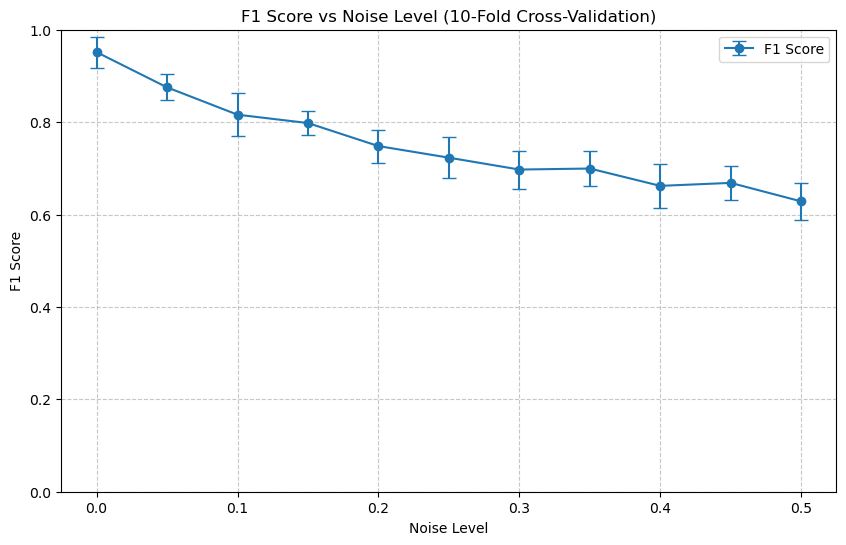

In [47]:
# plot the f1 scores with different noise levels
noise_levels = np.linspace(0, 0.5, 11)
f1_scores_mean = []
f1_scores_std = []

for noise_level in noise_levels:
    pipeline = Pipeline(steps=[
        ('noise_injection', FunctionTransformer(add_gaussian_noise, kw_args={'noise_level': noise_level}, validate=False)),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight=class_weights_dict))
    ])
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='f1_macro', n_jobs=-1)
    
    f1_scores_mean.append(scores.mean())
    f1_scores_std.append(scores.std())

plt.figure(figsize=(10, 6))
plt.errorbar(noise_levels, f1_scores_mean, yerr=f1_scores_std, fmt='-o', capsize=5, label='F1 Score')
plt.title('F1 Score vs Noise Level (10-Fold Cross-Validation)')
plt.xlabel('Noise Level')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()